In [6]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')



In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler

from src.data.train_dataset_EDA import load_train_with_features
from src.data.preprocess import clean_text
from src.features.tfidf import fit_tfidf_on_clean_text_column

plt.rcParams['figure.figsize'] = (12, 8)
print("Imports ready")



Imports ready


In [29]:
#TF-IDF train features
tfidf_vectorizer, X_train_tfidf, y_train_tfidf = fit_tfidf_on_clean_text_column()
print(f"TF-IDF Train: {X_train_tfidf.shape}")

#vectorize test data
test_df = pd.read_csv('data/emotion_processed_test.csv')
test_df['clean_text'] = test_df['text'].apply(clean_text)
X_test_tfidf = tfidf_vectorizer.transform(test_df['clean_text'])
y_test_tfidf = test_df['label'].values
print(f"TF-IDF Test: {X_test_tfidf.shape}")


TF-IDF Train: (16000, 20000)
TF-IDF Test: (2000, 20000)


In [4]:
#finding the hyperparameter value that produces the best results
C_values = [0.1, 1.0, 10.0,25.0, 50.0, 70.0, 100.0]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("C\tMean CV\tStd")
print("-"*20)
cv_results = {}

for C in C_values:
    svm = SVC(kernel='rbf', C=C, random_state=42)
    scores = cross_val_score(svm, X_train_tfidf, y_train_tfidf, cv=cv)
    cv_results[C] = scores.mean()
    print(f"{C}\t{scores.mean():.3f}\t{scores.std():.3f}")

best_C = max(cv_results, key=cv_results.get)
print(f"\nBest C: {best_C} ({cv_results[best_C]:.4f})")


C	Mean CV	Std
--------------------
0.1	0.335	0.000
1.0	0.769	0.007
10.0	0.805	0.004
25.0	0.805	0.004
50.0	0.805	0.004
70.0	0.805	0.004
100.0	0.805	0.004

Best C: 10.0 (0.8055)


In [34]:
svm_final = SVC(kernel='rbf', C=10.0, class_weight='balanced', probability=True, random_state=42)
svm_final.fit(X_train_tfidf, y_train_tfidf)

# Test predictions
y_pred = svm_final.predict(X_test_tfidf)

# Overall metrics DataFrame
emotion_names = ['Sadness', 'Joy', 'Love', 'Anger', 'Fear', 'Surprise']
prec, rec, f1, supp = precision_recall_fscore_support(y_test_tfidf, y_pred, labels=range(6), average=None)

df_overall = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Weighted', 'F1-Macro', 'F1-Micro'],
    'Score': [accuracy_score(y_test_tfidf, y_pred),
              f1_score(y_test_tfidf, y_pred, average='weighted'),
              f1_score(y_test_tfidf, y_pred, average='macro'),
              f1_score(y_test_tfidf, y_pred, average='micro')]
}).round(4)

# Per-class metrics DataFrame
df_per_class = pd.DataFrame({
    'Emotion': emotion_names,
    'Support': supp,
    'Precision': prec.round(3),
    'Recall': rec.round(3),
    'F1-Score': f1.round(3)
})

print("Overall Test Performance")
print(df_overall.to_string(index=False))
print()

print("Per-Class Performance")
print(df_per_class.to_string(index=False))
print()





Overall Test Performance
     Metric  Score
   Accuracy 0.8330
F1-Weighted 0.8253
   F1-Macro 0.7542
   F1-Micro 0.8330

Per-Class Performance
 Emotion  Support  Precision  Recall  F1-Score
 Sadness      581      0.870   0.914     0.892
     Joy      695      0.778   0.954     0.857
    Love      159      0.819   0.484     0.609
   Anger      275      0.923   0.745     0.825
    Fear      224      0.866   0.723     0.788
Surprise       66      0.800   0.424     0.554



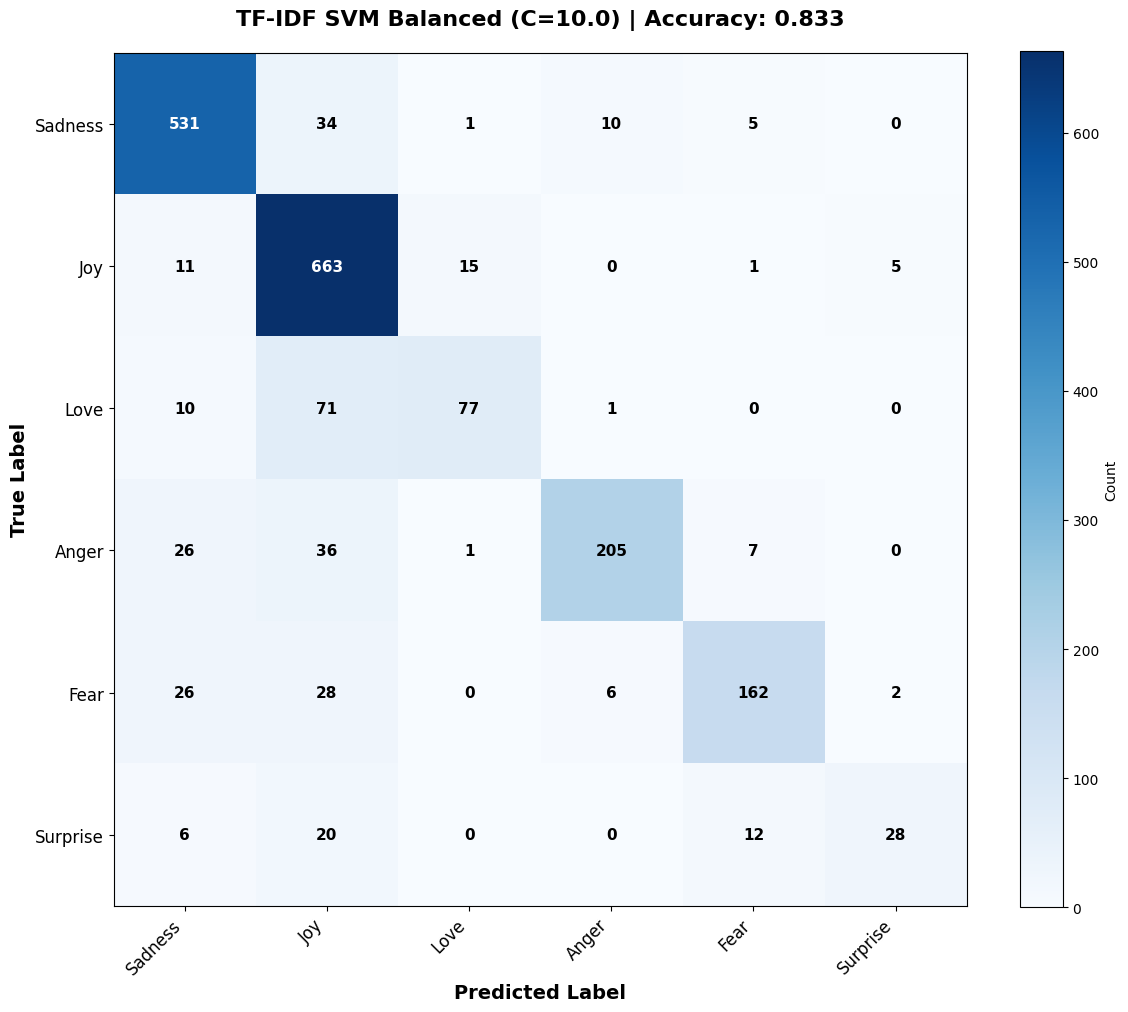

Confusion Matrix Summary:
          Pred_Sadness  Pred_Joy  Pred_Love  Pred_Anger  Pred_Fear  Pred_Surprise
Sadness            531        34          1          10          5              0
Joy                 11       663         15           0          1              5
Love                10        71         77           1          0              0
Anger               26        36          1         205          7              0
Fear                26        28          0           6        162              2
Surprise             6        20          0           0         12             28


In [35]:
emotion_names = ['Sadness', 'Joy', 'Love', 'Anger', 'Fear', 'Surprise']
cm = confusion_matrix(y_test_tfidf, y_pred)

current_acc = accuracy_score(y_test_tfidf, y_pred)
current_c = 10.0 

plt.figure(figsize=(12, 10))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.title(f'TF-IDF SVM Balanced (C={current_c}) | Accuracy: {current_acc:.3f}', 
          fontsize=16, fontweight='bold', pad=20)
plt.colorbar(label='Count')

plt.xticks(np.arange(6), emotion_names, rotation=45, ha='right', fontsize=12)
plt.yticks(np.arange(6), emotion_names, fontsize=12)
plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')


thresh = cm.max() / 2.
for i in range(6):
    for j in range(6):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Summary table below plot
print("Confusion Matrix Summary:")
cm_df = pd.DataFrame(cm, index=emotion_names, columns=[f'Pred_{name}' for name in emotion_names])
print(cm_df.astype(int).to_string())


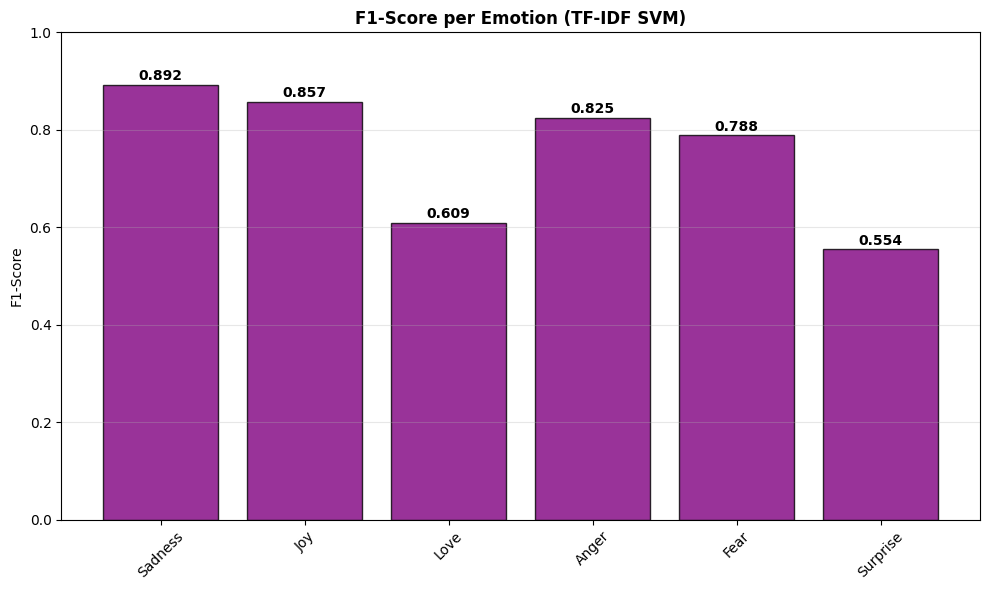

In [ ]:
emotion_names = ['Sadness', 'Joy', 'Love', 'Anger', 'Fear', 'Surprise']

plt.figure(figsize=(10, 6))
bars = plt.bar(emotion_names, f1_scores, 
               color='purple', alpha=0.8, edgecolor='black', linewidth=1)
plt.title('F1-Score per Emotion (TF-IDF SVM)', fontweight='bold')
plt.ylabel('F1-Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

for bar, f1 in zip(bars, f1_scores):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
             f'{f1:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()